# 17 Image generation | VAE with baseline

In [1]:
import os
import sys
import pathlib
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal

os.environ["KERAS_BACKEND"] = "jax"

import keras

from IPython.display import clear_output
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [2]:
def plot_history(history, metric):
    accuracy = history.history[metric]
    val_accuracy = history.history[f"val_{metric}"]
    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "r--", label=f"Training {metric}")
    plt.plot(epochs, val_accuracy, "b", label=f"Validation {metric}")
    plt.title(f"Training and validation {metric}")
    plt.legend()
    plt.show()

In [3]:
IMGGEN_DIR = pathlib.Path("image-generation")
IMGGEN_DIR.mkdir(exist_ok=True)

DATASET_DIR = pathlib.Path(IMGGEN_DIR / "datasets")
DATASET_DIR.mkdir(exist_ok=True)

MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

---

## Variational Autoencoders

### Implementing a VAE with Keras

#### Encoder (from images to latent space)

In [4]:
# todo: experiment with this
LATENT_DIM = 2

def build_encoder(latent_dim=2):
    image_inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
    x = keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(16, activation="relu")(x)
    # MEAN
    z_mean = keras.layers.Dense(latent_dim, name="z_mean")(x)
    # LOG OF VARIANCE = log(sigma**2) (log for math/stability)
    z_log_var = keras.layers.Dense(latent_dim, name="z_log_var")(x)
    return keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")
encoder = build_encoder(latent_dim=LATENT_DIM)

#### Latent-space-sampling layer

In [5]:
@keras.saving.register_keras_serializable()
class Sampler(keras.Layer):
    """From a mean mu and a log variance, sample a number with mu + sigma * epsilon"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # We need a seed generator to use functions from keras.random in call().
        self.seed_generator = keras.random.SeedGenerator()
        self.built = True

    def call(self, z_mean, z_log_var):
        batch_size = keras.ops.shape(z_mean)[0]
        z_size = keras.ops.shape(z_mean)[1]
        # draws a batch of random normal vectors
        epsilon = keras.random.normal(
            (batch_size, z_size), seed=self.seed_generator
        )
        # applies the VAE sampling formula (mu + sigma * epsilon)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

#### Decoder (from latent space to images)

In [6]:
def build_decoder(latent_dim=2):
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = keras.layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
    x = keras.layers.Reshape((7, 7, 64))(x)
    # CONV 2D TRANSPOSE
    x = keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    decoder_outputs = keras.layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    return keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder = build_decoder(latent_dim=LATENT_DIM)

#### The full VAE

In [7]:
@keras.saving.register_keras_serializable()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampler()
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        # GENERATION
        return self.encoder(inputs)

    def compute_loss(self, x, y, y_pred, sample_weight=None, training=True):
        # Argument x is the model's input.
        original = x
        # Argument y_pred is the output of call().
        z_mean, z_log_var = y_pred

        # This is our reconstructed image.
        reconstruction = self.decoder(self.sampler(z_mean, z_log_var))

        # LOSSES

        # a. reconstruction_loss: BCE between data & reconstructions (performed on each pixel,
        # then we sum across all pixels for each sample separately, then average the batch dim
        reconstruction_loss = keras.ops.mean(
            keras.ops.sum(
                keras.losses.binary_crossentropy(x, reconstruction),
                axis=(1, 2)
            )
        )

        # b. KL divergence (regularisation loss)(→ the latent distribution is close to a Gaussian)
        # divergence from the book, to be examined more (see: https://claude.ai/share/7ae043c8-fb5e-4e4e-92f6-7707ef927535)
        kl_loss = -0.5 * np.sum(
            1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var),
            axis=-1,
        )

        # c. total
        total_loss = reconstruction_loss + keras.ops.mean(kl_loss)

        # d. update our metrics trackers
        # self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return total_loss

    # plumbing: making this model serializable/reloadable ---------------------------------------
    # https://claude.ai/share/97fd35a0-aca9-4bb5-83ac-96bc392528f7
    def build(self, input_shape):
        # The encoder and decoder are already built as functional models,
        # so we just need to mark this model as built.
        self.encoder.build(input_shape)
        self.built = True

    def get_config(self):
        # Serialize the encoder and decoder configs so the full model
        # can be reconstructed from its config alone (required for saving).
        base_config = super().get_config()
        return {
            **base_config,
            "encoder": keras.layers.serialize(self.encoder),
            "decoder": keras.layers.serialize(self.decoder),
        }

    @classmethod
    def from_config(cls, config):
        # Deserialize the encoder and decoder before passing to __init__.
        encoder = keras.layers.deserialize(config.pop("encoder"))
        decoder = keras.layers.deserialize(config.pop("decoder"))
        return cls(encoder=encoder, decoder=decoder, **config)

#### Dataset

In [8]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
# mnist_digits = np.concatenate([x_train, x_test], axis=0)
# expand dim does (B, W, H) -> (B, W, H, 1)
mnist_train = np.expand_dims(x_train, -1).astype("float32") / 255
mnist_val = np.expand_dims(x_test, -1).astype("float32") / 255

#### Baseline

What could be a good baseline for our VAE? What we need is:
1. A way to perform compression (into `LATENT_DIM` dimensions) and then decompression, and apply the same loss (`binary_crossentropy`) between the real images and the reconstruction.
2. Retrieve the projections of the data points in the latent space, and use the same method (the KL divergence) to measure the discrepancy between the distribution of those points from a standard normal (which is the premise of the VAE).

It so happens that the optimal way to construct an autoencoder without learning / neural nets is to use [Principal Component Analysis (PCA)](https://en.wikipedia.org/wiki/Principal_component_analysis), that creates a new basis of orthogonal vectors capturing the variability of the data. By selecting only the `LATENT_DIM` first components (several vectors packed in a matrix), we can project our data into a `LATENT_DIM`-dimensional space (i.e. perform compression). We can use the transpose of that matrix to project back. This process is lossy, but it is the optimal linear autoencoder ([proof here](http://www.vision.jhu.edu/teaching/learning/deeplearning19/assets/Baldi_Hornik-89.pdf)).

For the whole baseline discussion, see [this](https://claude.ai/share/7e800d29-6c4d-44c3-bb9b-c746c757f947).

[`sklearn.decomposition.PCA` docs](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)  

In [26]:
# pca expects flat arrays
mnist_val_flat = mnist_val.reshape(len(mnist_val), -1)

# create pca & fit
pca = PCA(n_components=LATENT_DIM)
pca.fit(mnist_val_flat)

# project into LATENT_DIM
pca_latents = pca.transform(mnist_val_flat)
print(f"{pca_latents.shape = }")

# reconstruct, reshape
reconstruction = pca.inverse_transform(pca_latents).reshape(mnist_val.shape)
print(f"{reconstruction.shape = }")

# compute loss
loss = keras.ops.mean(
    keras.ops.sum(
        keras.losses.binary_crossentropy(
            mnist_val, reconstruction
        ),axis=(1, 2)
    )
)
loss = keras.ops.convert_to_numpy(loss).item()
print(f"Baseline reconstruction: {loss = }")

pca_latents.shape = (10000, 2)
reconstruction.shape = (10000, 28, 28, 1)
Baseline reconstruction: loss = 180.15826416015625


Now, our PCA model does two things: it centres the data (so the mean in our projection will automatically be zero), and ships with variances ([eigenvalues](https://stats.stackexchange.com/questions/346692/how-does-eigenvalues-measure-variance-along-the-principal-components-in-pca)), that are exactly what `z_log_var` is trying to model. We can thus plug those in the same `kl_loss` equation we have for our VAE.

Another option is to compute the KL divergence manually by:
1. Create a multivariate standard Gaussian (our reference distribution), and compute the log probability of our latent data points under it.
2. create a multivariate Gaussian with mean 0 and covariances `eigenvalues` (our predicted distribution), and compute the log probability of our latent data points under it.
3. The KL divergence is then `mean(log(predicted) - log(reference))`.

[`scipy.stats.multivariate_normal` docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html)

In [29]:
# PCA latents are ~N(0, diag(eigenvalues)), shape (LATENT_DIM,)
eigenvalues = pca.explained_variance_

# 1. Closed-form KL(N(0, diag(lambda)) || N(0, I)), same as VAE (z_mean is 0)
# -0.5 * np.sum(1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
kl_loss = np.mean(
        -0.5 * np.sum(
            1 + np.log(eigenvalues) - eigenvalues,
        axis=-1,
    )
)
print(f"Analytical KL(PCA latents || N(0,I)): {kl_loss:.3f}")

# 2. Running on samples: compute the probability of each sample given
#    a. a standard normal distribution
log_p = multivariate_normal(mean=np.zeros(LATENT_DIM), cov=np.eye(LATENT_DIM)).logpdf(pca_latents)
#    b. the distribution given by our PCA
log_q = multivariate_normal(mean=np.zeros(LATENT_DIM), cov=np.diag(eigenvalues)).logpdf(pca_latents)
# compute the KL
kl_pca_mc = np.mean(log_q - log_p)
print(f"Monte Carlo KL(PCA latents || N(0,I)): {kl_pca_mc:.3f}")

Analytical KL(PCA latents || N(0,I)): 2.123
Monte Carlo KL(PCA latents || N(0,I)): 2.122


#### Training

Note: the `Kernel Inception Distance` metric, present in the notebook [`lectures/10.more/chapter17_image-generation.Diffusion-metrics.ipynb`](https://github.com/jchwenger/DLWP/blob/main/lectures/10.more/chapter17_image-generation.Diffusion-metrics.ipynb`), could also work with the VAE (or any image generation model). The main thing to change would be to use `vae.decoder` to generate samples, and use those in the callback.

In [ ]:
vae = VAE(encoder, decoder)
vae.compile(
    optimizer=keras.optimizers.Adam(),
    run_eagerly=True,
)

VAE_NAME = "vae-mnist.keras"

BATCH_SIZE = 128

history = vae.fit(
    mnist_train,
    validation_data=mnist_val,
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            filepath=MODELS_DIR / VAE_NAME,
            save_best_only=True,
        ),
    ],
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 214ms/step - kl_loss: 3.4134 - loss: 216.9891 - reconstruction_loss: 213.5563 - val_kl_loss: 5.8464 - val_loss: 183.7258 - val_reconstruction_loss: 177.9202
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 180ms/step - kl_loss: 5.9570 - loss: 175.4928 - reconstruction_loss: 169.5331 - val_kl_loss: 6.0115 - val_loss: 171.0229 - val_reconstruction_loss: 165.0270
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 179ms/step - kl_loss: 6.2137 - loss: 168.7680 - reconstruction_loss: 162.5573 - val_kl_loss: 6.3990 - val_loss: 167.4034 - val_reconstruction_loss: 160.9986
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 184ms/step - kl_loss: 6.4239 - loss: 165.5384 - reconstruction_loss: 159.1162 - val_kl_loss: 6.4680 - val_loss: 163.9518 - val_reconstruction_loss: 157.4503
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 183ms/step - kl_loss: 6.5308 - loss: 163.2281 - reconstruction_loss: 156.7002 - val_kl_loss: 6.4352 - val_loss: 162.9362 - val_reconstruction_loss: 156

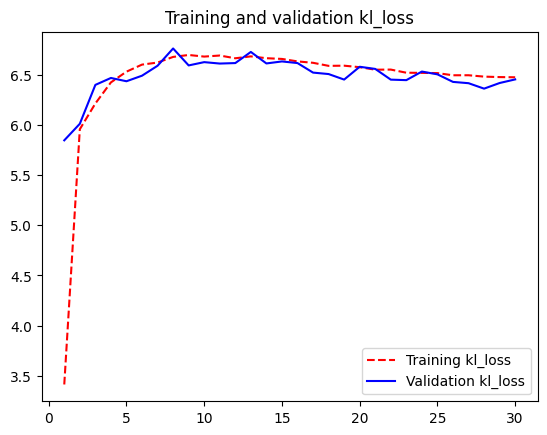

In [ ]:
plot_history(history, "kl_loss")

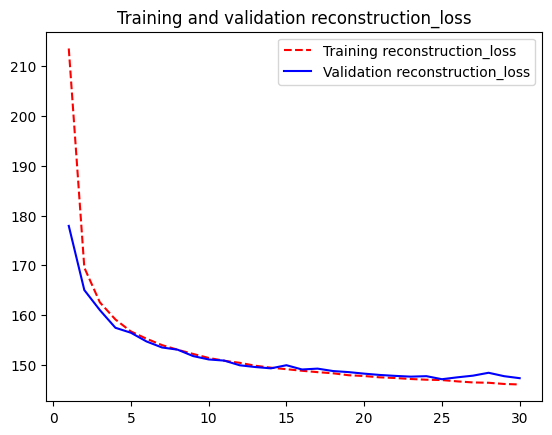

In [ ]:
plot_history(history, "reconstruction_loss")

#### Use your trained model

In [9]:
vae_reloaded = keras.models.load_model(MODELS_DIR / "vae-mnist.keras")

##### Encode and decode one image

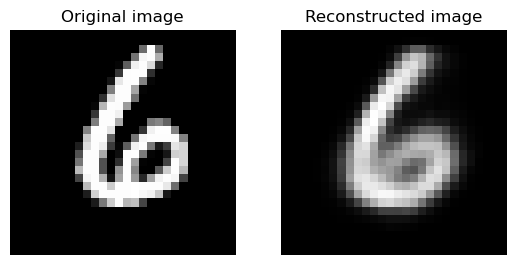

In [10]:
# select one MNIST image
n = np.random.randint(0, mnist_train.shape[0])
img = mnist_train[n:n+1]

# encode to mean and variance (each of dimension (batch, LATENT_DIM)
mu, logvar = vae_reloaded.encoder.predict(img, verbose=0)
# print(mu.shape, logvar.shape)

# sample a coordinate (LATENT_DIM) & reconstruct the image
z = Sampler()(mu, logvar)
reconstructed_img = vae_reloaded.decoder.predict(z, verbose=0)

fig, axs = plt.subplots(1,2)
axs[0].imshow(img[0], cmap="gray")
axs[0].set_title("Original image")
axs[0].axis("off")

axs[1].imshow(reconstructed_img[0], cmap="gray")
axs[1].set_title("Reconstructed image")
_ = axs[1].axis("off")

##### Generate an image from a random latent space coordinate

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

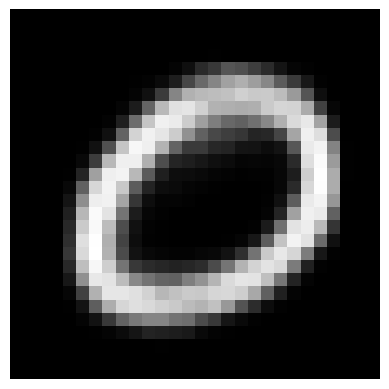

In [20]:
# We can also just sample a coordinate in the latent space
z = keras.random.normal((1,LATENT_DIM))
x_decoded = vae_reloaded.decoder.predict(z, verbose=0)
plt.imshow(x_decoded.reshape((28,28)), cmap="gray")
plt.axis("off")

##### Interpolation in latent space: linear vs spherical interpolation

In [21]:
def lerp(t, v1, v2):
    return (1 - t) * v1 + t * v2

def slerp(t, v1, v2):
    v1, v2 = keras.ops.cast(v1, "float32"), keras.ops.cast(v2, "float32")
    # normalize the vectors
    v1_norm = keras.ops.linalg.norm(keras.ops.ravel(v1))
    v2_norm = keras.ops.linalg.norm(keras.ops.ravel(v2))
    dot = keras.ops.sum(v1 * v2 / (v1_norm * v2_norm))
    # get the angle
    theta_0 = keras.ops.arccos(dot)
    # linear interpolation **on the angle**
    theta_t = theta_0 * t
    # use the angle to interpolate in coordinate space
    sin_theta_0 = keras.ops.sin(theta_0)
    sin_theta_t = keras.ops.sin(theta_t)
    s0 = keras.ops.sin(theta_0 - theta_t) / sin_theta_0
    s1 = sin_theta_t / sin_theta_0
    return s0 * v1 + s1 * v2

Demo of the linear vs spherical linear interpolation functions. There is a difference, if you test other seeds, although the difference is not 100% stark – it might be a good experiment to see if having a higher-dimensional latent space (than `2`, as now) makes the difference between the two methods clearer.

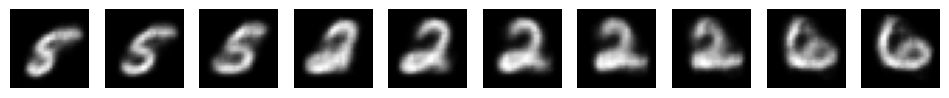

In [32]:
keras.utils.set_random_seed(8)
zs = keras.random.normal((2,LATENT_DIM))
steps = 10

zs_lerp = []
for t in np.linspace(0, 1, steps):
    # linear interpolation
    zs_lerp.append(lerp(t, zs[0:1], zs[1:2]))

x_lerp = vae_reloaded.decoder.predict(keras.ops.concatenate(zs_lerp), verbose=0)

fig, axs = plt.subplots(1, steps, figsize=(12,5))
for i in range(steps):
    axs[i].imshow(x_lerp[i].reshape((28,28)), cmap="gray")
    axs[i].axis("off") 

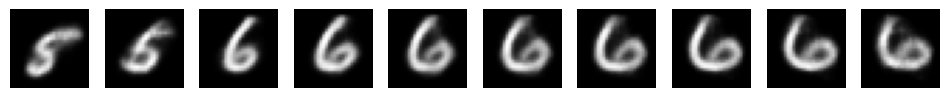

In [33]:
zs_slerp = []
for t in np.linspace(0, 1, steps):
    # spherical linear interpolation
    zs_slerp.append(slerp(t, zs[0:1], zs[1:2]))

x_slerp = vae_reloaded.decoder.predict(keras.ops.concatenate(zs_slerp), verbose=0)

fig, axs = plt.subplots(1, steps, figsize=(12,7))
for i in range(steps):
    axs[i].imshow(x_slerp[i].reshape((28,28)), cmap="gray")
    axs[i].axis("off")   

##### Sampling a grid of images from the `LATENT_DIM`-D latent space

In this example, we create select two dimensions to create a grid of points from `-1` to `1` for both, create these pairs, decode all points from latent space back to images, and stitch them all into one picture. Note that we can use parallel computing to decode all points in one go (like a batch). This version works in arbitrary dimensions, not just 2D!

In [34]:
# see: https://claude.ai/share/d78a3162-5957-442e-aece-e6c6fc999353
def plot_latent_space(vae, first_dim=0, second_dim=1):
    n = 30
    img_size = 28
    # empty pixels
    figure = np.zeros((img_size * n, img_size * n))

    # linearly spaced values for x
    grid_x = np.linspace(-1, 1, n)
    # linearly spaced values for y
    grid_y = np.linspace(-1, 1, n)[::-1]

    # first_dim & second_dim must not exceed LATENT_DIM - 1!

    # # option 1: create just zeros
    # z_samples = np.zeros((n * n, LATENT_DIM))
    
    # option 2: create one random array & repeat it
    z_samples = np.random.normal(size=(1, LATENT_DIM))
    z_samples = np.tile(z_samples, n*n).reshape(-1, LATENT_DIM)
    
    # for all samples, vary linearly along first_dim
    # (along rows, so -1, -1, -1, -1, -1, -.5, -.5, -.5, -.5, -.5, etc.)
    z_samples[:, first_dim] = np.repeat(grid_x, n)
    # for all samples, vary linearly along second_dim
    # (along columns, so -1, -.5, 0, .5, 1, -.5, 0, etc.)
    z_samples[:, second_dim] = np.tile(grid_y, n)
    # dims 2..N stay at 0

    # decode all images from samples in one batch
    x_decoded = vae.decoder.predict(z_samples, verbose=0)

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            # 3. include image into our grid
            img = x_decoded[i * n + j].reshape(img_size, img_size)
            figure[
                i * img_size : (i + 1) * img_size,
                j * img_size : (j + 1) * img_size,
            ] = img

    plt.figure(figsize=(15, 15))
    start_range = img_size // 2
    end_range = n * img_size + start_range
    pixel_range = np.arange(start_range, end_range, img_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.axis("off")
    plt.imshow(figure, cmap="Greys_r")

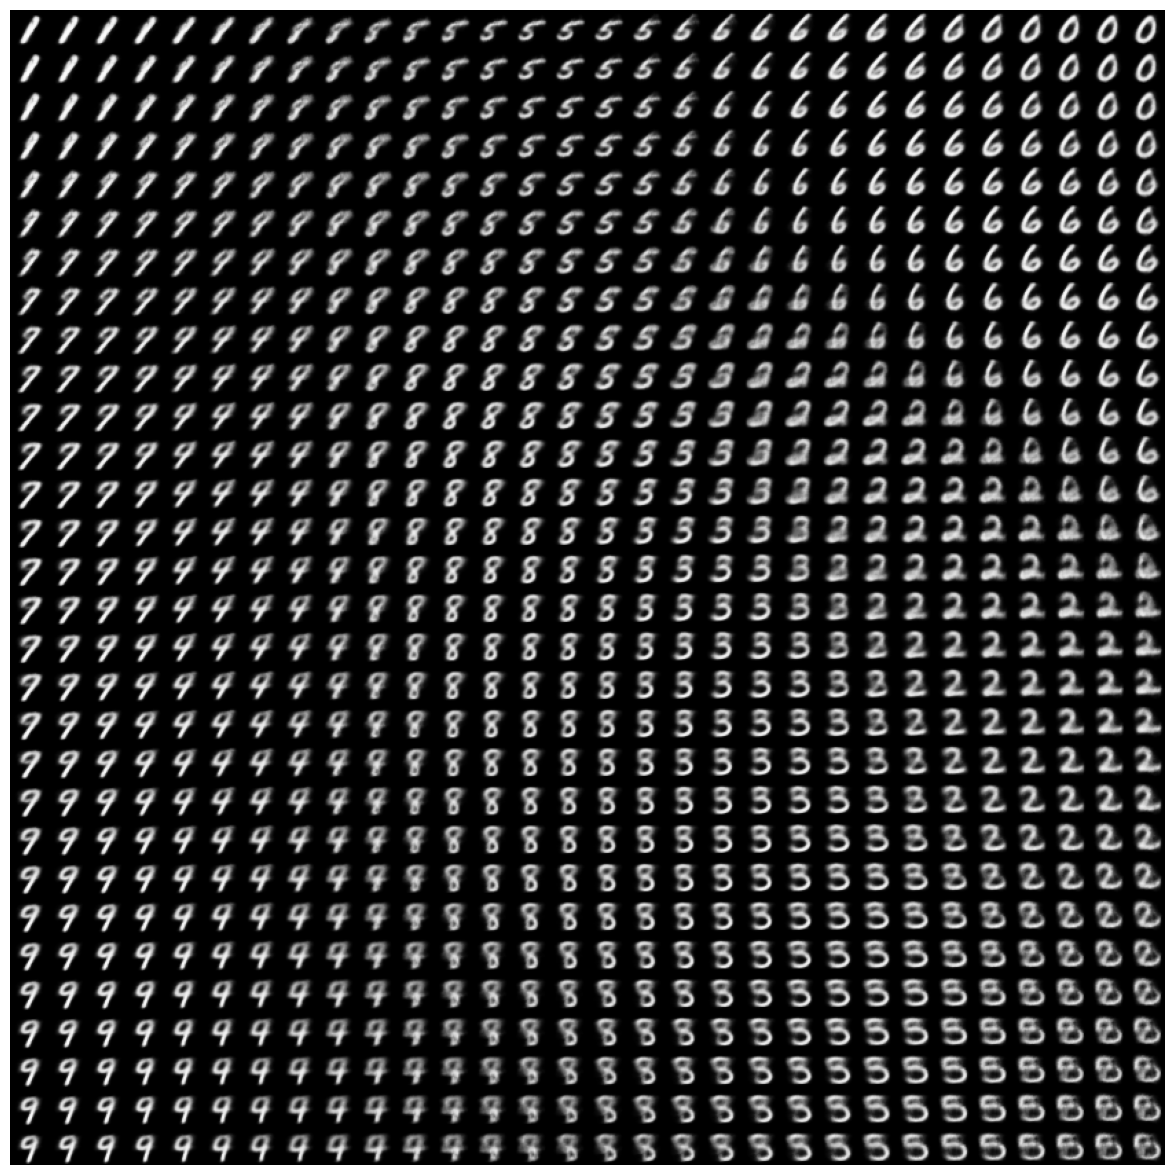

In [35]:
plot_latent_space(vae_reloaded, first_dim=0, second_dim=1)

## Save models to Google Drive


In [ ]:
EXPORT=False

if EXPORT:
    # zip models
    !zip vae-metrics.models.zip {MODELS_DIR}/*
    # connect to drive
    from google.colab import drive
    drive.mount('/content/drive')
    # copy zip to drive (adjust folder as needed)
    !cp vae-metrics.models.zip drive/MyDrive/gold/IS53024B-Artificial-Intelligence/models